# exp-sparse-boosting-01 — 구조화 sparse LightGBM 스크리닝

## 목적
기존 LR의 변이 표현을 유지하되, 비선형 분기 기반 모델이 어떤 구조화 입력에서 유효한지 seed 42의 동일 Stratified 5-fold로 비교한다. 이 노트북은 **입력 표현 스크리닝**이며 LightGBM 파라미터 탐색이 아니다.

### 고정 모델
- LightGBM multiclass, `n_estimators=600`, `learning_rate=0.03`, `num_leaves=15`, `min_child_samples=25`
- `colsample_bytree=0.70`, `subsample=0.80`, `subsample_freq=1`, `reg_lambda=2.0`, `class_weight='balanced'`
- seed 42, Stratified 5-fold. 후보별 동일 fold를 공유한다.

### 비교 후보
1. `structured_core`: 원본 gene mutation + count/type/truncation/recurrent/A_pair/exact/topology/contrast
2. `structured_core_signature`: core + gene×기능유형×50aa 위치구간 signature. token은 fold-train에서 3명 이상 발생 시만 선택
3. `reduced_raw_gene_1000`: core의 raw gene mutation만 fold-train 클래스별 mutation-rate 차이 상위 1,000개로 축소. 나머지 구조 피처는 유지

### 규칙 및 채택 기준
- OOF 동안 `train.csv`만 읽는다. test 통계·선택·fit은 전혀 사용하지 않는다.
- train은 결측이 없어야 하며, 결과에 `leakage_check=True`, `nan_as_mutation_count=0`을 기록한다.
- seed42에서 유망 후보만 다음 단계에서 42/777/2024 확정 검증한다. 이 단계에서는 새 파라미터·새 피처·새 blend를 추가 탐색하지 않는다.


In [1]:
from pathlib import Path
import subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt

def find_exp_model():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct = path / 'common' / 'exp_sparse_boosting_runner.py'
        project = path / 'experiments' / 'gs' / 'notebooks' / 'exp_model' / 'common' / 'exp_sparse_boosting_runner.py'
        if direct.exists():
            return path
        if project.exists():
            return project.parent.parent
    raise FileNotFoundError('sparse boosting runner를 찾지 못했습니다.')

EXP_MODEL = find_exp_model()
RUNNER = EXP_MODEL / 'common' / 'exp_sparse_boosting_runner.py'
RESULT_DIR = EXP_MODEL / 'result'
RUN_ID = 'exp-sparse-boosting-01'
SEED = 42
RUN_EXPERIMENT = True
print({'runner': RUNNER, 'result_dir': RESULT_DIR, 'seed': SEED, 'variants': 3})


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model/common/exp_sparse_boosting_runner.py'), 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model/result'), 'seed': 42, 'variants': 3}


In [2]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--seed', str(SEED), '--run-id', RUN_ID]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    assert process.stdout is not None
    tail = []
    for line in process.stdout:
        print(line, end='')
        tail = (tail + [line])[-80:]
    return_code = process.wait()
    if return_code:
        raise RuntimeError(f'sparse-boosting runner failed (exit={return_code}). Last output:\n' + ''.join(tail))



row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 383.03it/s]

sparse-boosting | seed 42:   0%|          | 0/5 [00:00<?, ?fold/s]
sparse-boosting | seed 42:  20%|██        | 1/5 [05:55<23:40, 355.19s/fold]
sparse-boosting | seed 42:  40%|████      | 2/5 [12:57<19:44, 394.90s/fold]
sparse-boosting | seed 42:  60%|██████    | 3/5 [20:04<13:38, 409.28s/fold]
sparse-boosting | seed 42:  80%|████████  | 4/5 [27:09<06:55, 415.46s/fold]
sparse-boosting | seed 42: 100%|██████████| 5/5 [34:03<00:00, 415.04s/fold]
sparse-boosting | seed 42: 100%|██████████| 5/5 [34:03<00:00, 408.70s/fold]
[
  {
    "experiment_id":"exp-sparse-boosting-01",
    "variant":"structured_core",
    "seed":42,
    "oof_macro_f1":0.4598652578,
    "oof_accuracy":0.4415416868,
    "delta_vs_structured_core":0.0,
    "feature_count_mean":8175.2,
    "runtime_seconds":2043.534676375,
    "convergence_warning_count":0,
    "leakage_check":true,
    "nan_as_mutation_count":0,
    "position_bin_width":50,
  

,experiment_id,variant,seed,oof_macro_f1,oof_accuracy,delta_vs_structured_core,feature_count_mean,runtime_seconds,convergence_warning_count,leakage_check,...,lgbm_min_child_samples,lgbm_colsample_bytree,lgbm_subsample,lgbm_subsample_freq,lgbm_reg_lambda,lgbm_reg_alpha,lgbm_class_weight,lgbm_n_jobs,lgbm_verbosity,lgbm_force_col_wise
1,exp-sparse-boosting-01,structured_core_signature,42,0.465447,0.445735,0.005581,35183.0,2043.553042,0,True,...,25,0.7,0.8,1,2.0,0.0,balanced,-1,-1,True
2,exp-sparse-boosting-01,reduced_raw_gene_1000,42,0.463747,0.446057,0.003881,4946.6,2043.570830,0,True,...,25,0.7,0.8,1,2.0,0.0,balanced,-1,-1,True
0,exp-sparse-boosting-01,structured_core,42,0.459865,0.441542,0.000000,8175.2,2043.534676,0,True,...,25,0.7,0.8,1,2.0,0.0,balanced,-1,-1,True


,variant,fold_macro_f1_mean,fold_macro_f1_std,feature_count_mean,signature_feature_count_mean
0,reduced_raw_gene_1000,0.461893,0.018630,4946.6,27007.8
1,structured_core,0.458294,0.017505,8175.2,27007.8
2,structured_core_signature,0.463048,0.020322,35183.0,27007.8


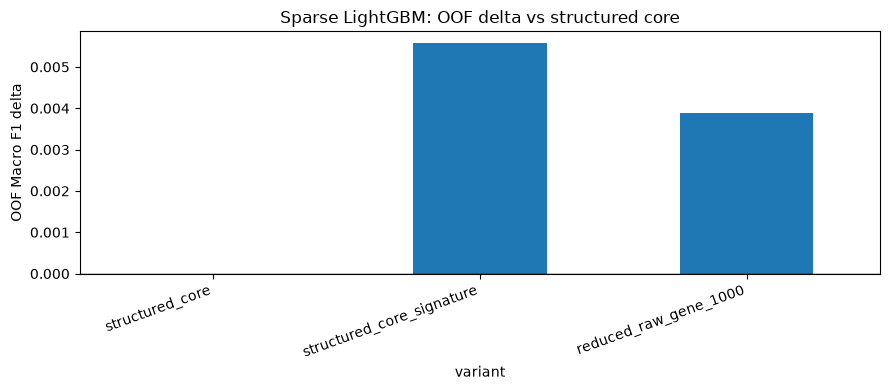

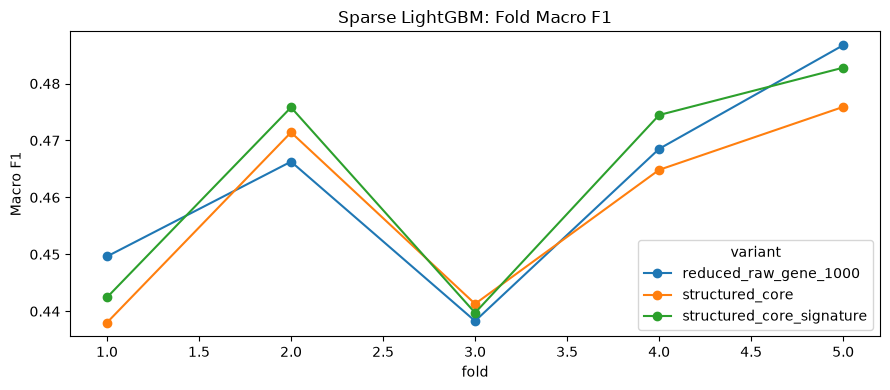

In [3]:
summary = pd.read_csv(RESULT_DIR / f'{RUN_ID}_seed{SEED}_summary.csv')
folds = pd.read_csv(RESULT_DIR / f'{RUN_ID}_seed{SEED}_folds.csv')
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
display(summary.sort_values('oof_macro_f1', ascending=False))
display(folds.groupby('variant', as_index=False).agg(fold_macro_f1_mean=('fold_macro_f1', 'mean'), fold_macro_f1_std=('fold_macro_f1', 'std'), feature_count_mean=('feature_count', 'mean'), signature_feature_count_mean=('signature_feature_count', 'mean')))

ax = summary.plot.bar(x='variant', y='delta_vs_structured_core', legend=False, figsize=(9, 4), title='Sparse LightGBM: OOF delta vs structured core')
ax.axhline(0, color='black', linewidth=1); ax.set_ylabel('OOF Macro F1 delta')
plt.xticks(rotation=20, ha='right'); plt.tight_layout()
plt.savefig(RESULT_DIR / f'{RUN_ID}_seed{SEED}_delta.png', dpi=160)
plt.show()

pivot = folds.pivot(index='fold', columns='variant', values='fold_macro_f1')
ax = pivot.plot(marker='o', figsize=(9, 4), title='Sparse LightGBM: Fold Macro F1')
ax.set_ylabel('Macro F1'); plt.tight_layout()
plt.savefig(RESULT_DIR / f'{RUN_ID}_seed{SEED}_fold_macro_f1.png', dpi=160)
plt.show()
